In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (confusion_matrix, accuracy_score, classification_report, precision_score,
                             recall_score, f1_score, roc_curve, auc, ConfusionMatrixDisplay)
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import GridSearchCV
from sklearn.naive_bayes import GaussianNB, ComplementNB, MultinomialNB
from sklearn.tree import DecisionTreeClassifier, plot_tree

## Binary Classification

In [2]:
df = pd.read_csv('boardgames_dataset.csv')
# Droppa name da df
df = df.drop(columns=['Name'])
# Droppa NumWeightVotes, NumUserRatings, NumAlternates, NumExpansions, NumImplementations
df = df.drop(columns=['NumWeightVotes', 'NumUserRatings', 'NumAlternates', 'NumExpansions', 'NumImplementations'])


In [3]:
# Calculate correlation with log_NumUserRatings
correlation = df.corr()['log_NumUserRatings'].sort_values(ascending=False)
correlation


log_NumUserRatings        1.000000
log_NumWeightVotes        0.882101
InterestScore             0.755832
NumAlternates_log         0.449708
Cat:Strategy              0.433174
NumExpansions_log         0.409864
Cat:Family                0.380101
Rating                    0.289033
NumImplementations_log    0.279900
Cat:Thematic              0.263570
Cat:Party                 0.192814
GameWeight                0.142997
IsReimplementation        0.122626
YearPublished             0.082450
Kickstarted               0.065819
MaxPlayers                0.045944
Cat:CGS                   0.045399
PlaytimeComAvg           -0.004992
Cat:Abstract             -0.005194
ComAgeRec                -0.021856
Cat:Childrens            -0.023813
MinPlayers               -0.034214
Cat:War                  -0.133996
Name: log_NumUserRatings, dtype: float64

In [4]:
threshold = df['log_NumUserRatings'].median()
df['HighInteraction'] = (df['log_NumUserRatings'] >= threshold).astype(int)
print(f"La soglia è {threshold}")
# # Print hoy many values of log_NumUserRatings that are greater than or equal to the threshold
# print(f"Numero di giochi con alto engagement: {df['HighInteraction'].sum()}")
# print(f"Numero di giochi con basso engagement: {len(df) - df['HighInteraction'].sum()}")

La soglia è 4.8283137373023015


In [39]:
# Define features to drop
target_related = ['HighInteraction', 'log_NumUserRatings', 
                  'log_NumWeightVotes', 'InterestScore']
weak_features = ['PlaytimeComAvg', 'Cat:Childrens', 'Cat:Abstract', 
                 'MinPlayers', 'ComAgeRec']

# 3. Create X (drop everything at once)
X = df.drop(columns=target_related + weak_features)

y = df['HighInteraction']

In [40]:
# Splitto in train e test set
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,          # 80/20 
    stratify=y,             
    random_state=42
)


In [41]:
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))


HighInteraction
1    0.500441
0    0.499559
Name: proportion, dtype: float64
HighInteraction
1    0.500588
0    0.499412
Name: proportion, dtype: float64


In [42]:
# df_train_corr = X_train.copy()
# df_train_corr['HighInteraction'] = y_train

# correlation_rating = df_train_corr.corr()['HighInteraction'].drop('HighInteraction')
# print(correlation_rating.sort_values(ascending=False))


In [43]:
num_features = [
    'GameWeight',
    'YearPublished',
    'MaxPlayers',
    'NumExpansions_log',
    'NumAlternates_log',
    'NumImplementations_log'
]

bin_features = [
    'IsReimplementation',
    'Kickstarted',
    'Cat:Strategy',
    'Cat:War',
    'Cat:Thematic',
    'Cat:Family',
    'Cat:CGS',
    'Cat:Party',
]

#from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled_num = scaler.fit_transform(X_train[num_features])
X_test_scaled_num = scaler.transform(X_test[num_features])

import pandas as pd

X_train_scaled = pd.DataFrame(
    X_train_scaled_num,
    columns=num_features,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled_num,
    columns=num_features,
    index=X_test.index
)

# Aggiungi le feature binarie
X_train_scaled = pd.concat([X_train_scaled, X_train[bin_features]], axis=1)
X_test_scaled = pd.concat([X_test_scaled, X_test[bin_features]], axis=1)
#print(X_train_scaled.head())


### KNN (Binary Classification) 

In [44]:
selected_columns = [
    'GameWeight',
    'YearPublished',
    'MaxPlayers',
    'NumExpansions_log',
    'NumAlternates_log',
    'NumImplementations_log',
    'IsReimplementation',
    'Kickstarted',
    'Cat:Strategy',
    'Cat:War',
    'Cat:Thematic',
    'Cat:Family',
    'Cat:CGS',
    'Cat:Party',
]

# X per KNN
X_train_knn = X_train_scaled[selected_columns]
X_test_knn  = X_test_scaled[selected_columns]

# y per KNN (già separata)
y_train_knn = y_train
y_test_knn  = y_test

print(X_train_knn.shape, X_test_knn.shape)
print(y_train_knn.shape, y_test_knn.shape)

X_train_knn.head()

(16995, 14) (4249, 14)
(16995,) (4249,)


,GameWeight,YearPublished,MaxPlayers,NumExpansions_log,NumAlternates_log,NumImplementations_log,IsReimplementation,Kickstarted,Cat:Strategy,Cat:War,Cat:Thematic,Cat:Family,Cat:CGS,Cat:Party
15881,-1.309663,-0.187717,0.559635,-0.492868,0.301338,-0.513911,0,0,0,0,0,0,0,0
15365,0.932899,-1.841468,-0.284436,-0.492868,-0.686348,-0.513911,0,0,0,1,0,0,0,0
10654,0.330190,0.993534,0.559635,-0.492868,-0.686348,-0.513911,0,1,0,0,0,0,0,0
4971,-0.678950,0.757284,0.559635,1.107251,-0.686348,-0.513911,0,0,0,0,0,0,0,0
19396,-0.048237,-1.998968,-1.128507,-0.492868,-0.686348,-0.513911,0,0,0,1,0,0,0,0


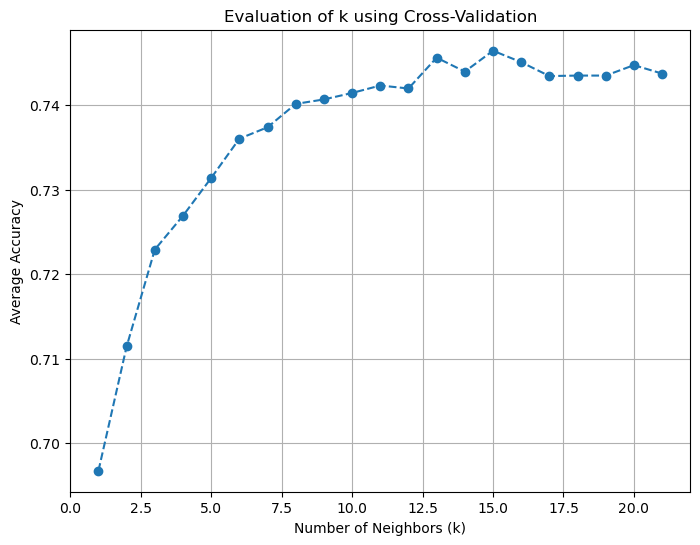

In [45]:
# Search for the best k value
k_values = range(1, 22)
cv_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_knn, y_train_knn, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())

# Plot to visualize k search
plt.figure(figsize=(8, 6))
plt.plot(k_values, cv_scores, marker='o', linestyle='--')
plt.title('Evaluation of k using Cross-Validation')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Average Accuracy')
plt.grid()
plt.show()

In [46]:
# Best k value
best_k = k_values[np.argmax(cv_scores)]
print(f"Best k value: {best_k}")

Best k value: 15


In [47]:
# Train the model with the best k

knn = KNeighborsClassifier(
        n_neighbors=best_k,
        weights='uniform',  # Example of custom
        metric="manhattan"  # Example of custom
)
knn.fit(X_train_knn, y_train_knn)

y_pred = knn.predict(X_test_knn)

In [48]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test_knn, y_pred)

precision_macro = precision_score(y_test_knn, y_pred, average='macro', zero_division=0)
recall_macro    = recall_score(y_test_knn, y_pred, average='macro', zero_division=0)
f1_macro        = f1_score(y_test_knn, y_pred, average='macro', zero_division=0)

precision_weighted = precision_score(y_test_knn, y_pred, average='weighted', zero_division=0)
recall_weighted    = recall_score(y_test_knn, y_pred, average='weighted', zero_division=0)
f1_weighted        = f1_score(y_test_knn, y_pred, average='weighted', zero_division=0)

print("📊 RISULTATI KNN")
print(f"Accuracy: {accuracy:.4f}")
print("\nMacro average:")
print(f"  Precision: {precision_macro:.4f}")
print(f"  Recall:    {recall_macro:.4f}")
print(f"  F1-score:  {f1_macro:.4f}")

print("\nWeighted average:")
print(f"  Precision: {precision_weighted:.4f}")
print(f"  Recall:    {recall_weighted:.4f}")
print(f"  F1-score:  {f1_weighted:.4f}")


📊 RISULTATI KNN
Accuracy: 0.7439

Macro average:
  Precision: 0.7569
  Recall:    0.7441
  F1-score:  0.7407

Weighted average:
  Precision: 0.7570
  Recall:    0.7439
  F1-score:  0.7407


In [49]:
from sklearn.metrics import classification_report
print(classification_report(y_test_knn, y_pred))

              precision    recall  f1-score   support

           0       0.70      0.86      0.77      2122
           1       0.82      0.63      0.71      2127

    accuracy                           0.74      4249
   macro avg       0.76      0.74      0.74      4249
weighted avg       0.76      0.74      0.74      4249



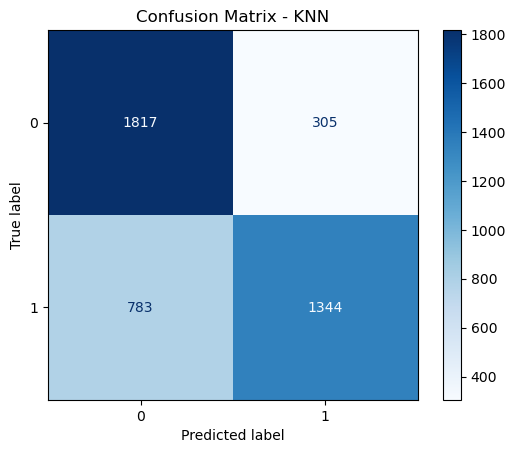

In [50]:
from sklearn.metrics import ConfusionMatrixDisplay

# Lascia che lo calcoli automaticamente
ConfusionMatrixDisplay.from_predictions(y_test_knn, y_pred, cmap=plt.cm.Blues)
plt.title('Confusion Matrix - KNN')
plt.show()

📈 ROC CURVE ANALYSIS - KNN


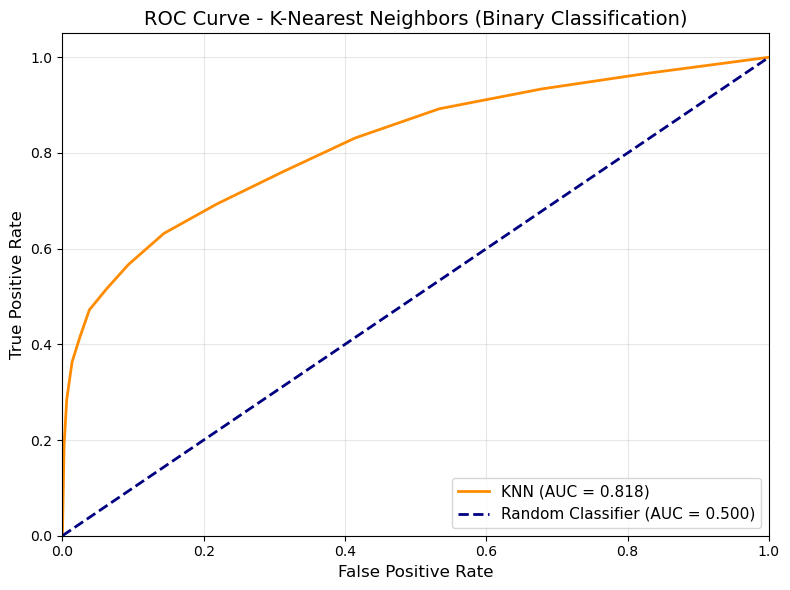


✅ ROC-AUC Score: 0.8179


In [51]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

print("="*60)
print("📈 ROC CURVE ANALYSIS - KNN")
print("="*60)

# Usa il modello KNN che hai già addestrato
# Assicurati di aver eseguito prima:
# knn = KNeighborsClassifier(n_neighbors=15, weights='uniform', metric='manhattan')
# knn.fit(X_train_scaled, y_train)

# 1. Ottieni le probabilità predette
y_proba = knn.predict_proba(X_test_scaled)[:, 1]  # ← Usa 'knn' invece di 'knn_optimized'

# 2. Calcola ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

# 3. Plot
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, 
         label=f'KNN (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', 
         label='Random Classifier (AUC = 0.500)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve - K-Nearest Neighbors (Binary Classification)', fontsize=14)
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n✅ ROC-AUC Score: {roc_auc:.4f}")

In [52]:
print("="*60)
print("🔍 KNN OVERFITTING ANALYSIS - BINARY CLASSIFICATION")
print("="*60)
print(f"Best k:             {best_k}")
print(f"Weights:            uniform")
print(f"Metric:             manhattan")

# Train accuracy
y_train_pred = knn.predict(X_train_knn)
train_acc = accuracy_score(y_train_knn, y_train_pred)

# Test accuracy (già calcolato)
test_acc = accuracy_score(y_test_knn, y_pred)

print(f"\nTrain Accuracy:     {train_acc:.4f}")
print(f"Test Accuracy:      {test_acc:.4f}")
print(f"Overfitting Gap:    {(train_acc - test_acc)*100:+.2f}%")

if train_acc == 1.0:
    print("\n⚠️ WARNING: Perfect training accuracy detected!")
    print("This should NOT happen with k=20. Check for data leakage.")

🔍 KNN OVERFITTING ANALYSIS - BINARY CLASSIFICATION
Best k:             15
Weights:            uniform
Metric:             manhattan

Train Accuracy:     0.7813
Test Accuracy:      0.7439
Overfitting Gap:    +3.73%


# NAIVE-BAYES CLASSIFIER

In [53]:
from sklearn.naive_bayes import CategoricalNB
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import pandas as pd

# ══════════════════════════════════════════════════════════════
# CATEGORICAL NAIVE BAYES - stesso subset del KNN 
# ══════════════════════════════════════════════════════════════

# 1) Subset identico a KNN
selected_columns = [
    'GameWeight',
    'YearPublished',
    'MaxPlayers',
    'NumExpansions_log',
    'NumAlternates_log',
    'NumImplementations_log',
    'IsReimplementation',
    'Kickstarted',
    'Cat:Strategy',
    'Cat:War',
    'Cat:Thematic',
    'Cat:Family',
    'Cat:CGS',
    'Cat:Party',
]

# Filtra solo quelle effettivamente presenti (usa X_train/X_test, non scaled)
selected_columns = [c for c in selected_columns if c in X_train.columns and c in X_test.columns]

# 2) Separa numeriche vs binarie SOLO all'interno del subset
# (aggiusta qui se qualche tua feature "binaria" in realtà non è 0/1)
num_features_cnb = [
    'GameWeight',
    'YearPublished',
    'MaxPlayers',
    'NumExpansions_log',
    'NumAlternates_log',
    'NumImplementations_log'
]
bin_features_cnb = [
    'IsReimplementation',
    'Kickstarted',
    'Cat:Strategy',
    'Cat:War',
    'Cat:Thematic',
    'Cat:Family',
    'Cat:CGS',
    'Cat:Party',
]

# Tieni solo quelle presenti davvero (robustezza)
num_features_cnb = [c for c in num_features_cnb if c in selected_columns]
bin_features_cnb = [c for c in bin_features_cnb if c in selected_columns]

# 3) Discretizza SOLO numeriche (in 10 bin, ordinali 0..9)
discretizer = KBinsDiscretizer(n_bins=10, encode='ordinal', strategy='quantile')

X_train_disc = discretizer.fit_transform(X_train[num_features_cnb])
X_test_disc  = discretizer.transform(X_test[num_features_cnb])

X_train_cnb = pd.DataFrame(X_train_disc, columns=num_features_cnb, index=X_train.index)
X_test_cnb  = pd.DataFrame(X_test_disc,  columns=num_features_cnb, index=X_test.index)

# 4) Aggiungi binarie (già categoriche: 0/1)
if len(bin_features_cnb) > 0:
    X_train_cnb = pd.concat([X_train_cnb, X_train[bin_features_cnb]], axis=1)
    X_test_cnb  = pd.concat([X_test_cnb,  X_test[bin_features_cnb]], axis=1)

# 5) Riordina le colonne per essere IDENTICHE e nello stesso ordine del subset KNN
final_cols = [c for c in selected_columns if c in X_train_cnb.columns]
X_train_cnb = X_train_cnb[final_cols]
X_test_cnb  = X_test_cnb[final_cols]

# 6) Assicurati interi non negativi (CategoricalNB requirement)
X_train_cnb = X_train_cnb.astype(int)
X_test_cnb  = X_test_cnb.astype(int)

print("✅ Features preparate per CategoricalNB (stesso subset del KNN)")
print(f"Columns used ({len(final_cols)}): {final_cols}")
print(f"Shape train: {X_train_cnb.shape}")
print(f"Shape test:  {X_test_cnb.shape}")
print("\nRange valori (dopo discretizzazione):")
print(f"Min: {X_train_cnb.min().min()}")
print(f"Max: {X_train_cnb.max().max()}")
print("\nEsempio prima riga:")
print(X_train_cnb.head(1))

# ══════════════════════════════════════════════════════════════
# MODELLO CATEGORICAL NAIVE BAYES
# ══════════════════════════════════════════════════════════════

cnb = CategoricalNB()
cnb.fit(X_train_cnb, y_train)

y_pred_cnb = cnb.predict(X_test_cnb)

print("\n" + "="*60)
print("CATEGORICAL NAIVE BAYES - RISULTATI (subset KNN)")
print("="*60)
print(f"\nAccuracy: {accuracy_score(y_test, y_pred_cnb):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_cnb))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_cnb))

# ══════════════════════════════════════════════════════════════
# 2) GAUSSIAN NAIVE BAYES (feature continue)
# ══════════════════════════════════════════════════════════════
# Consiglio: usa lo stesso scaling del KNN (X_train_scaled / X_test_scaled)
# perché GaussianNB assume feature continue (non discretizzate).

# Se hai già questi DataFrame:
# X_train_scaled, X_test_scaled (stesse colonne di X_train/X_test)
X_train_gnb = X_train_scaled[selected_columns]
X_test_gnb  = X_test_scaled[selected_columns]

gnb = GaussianNB()
gnb.fit(X_train_gnb, y_train)
y_pred_gnb = gnb.predict(X_test_gnb)

print("\n" + "="*60)
print("GAUSSIAN NAIVE BAYES - RISULTATI (subset KNN)")
print("="*60)
print(f"Accuracy: {accuracy_score(y_test, y_pred_gnb):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_gnb))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_gnb))


✅ Features preparate per CategoricalNB (stesso subset del KNN)
Columns used (14): ['GameWeight', 'YearPublished', 'MaxPlayers', 'NumExpansions_log', 'NumAlternates_log', 'NumImplementations_log', 'IsReimplementation', 'Kickstarted', 'Cat:Strategy', 'Cat:War', 'Cat:Thematic', 'Cat:Family', 'Cat:CGS', 'Cat:Party']
Shape train: (16995, 14)
Shape test:  (4249, 14)

Range valori (dopo discretizzazione):
Min: 0
Max: 9

Esempio prima riga:
       GameWeight  YearPublished  MaxPlayers  NumExpansions_log  \
15881           0              3           4                  0   

       NumAlternates_log  NumImplementations_log  IsReimplementation  \
15881                  1                       0                   0   

       Kickstarted  Cat:Strategy  Cat:War  Cat:Thematic  Cat:Family  Cat:CGS  \
15881            0             0        0             0           0        0   

       Cat:Party  
15881          0  

CATEGORICAL NAIVE BAYES - RISULTATI (subset KNN)

Accuracy: 0.7609

Classification 

/opt/anaconda3/lib/python3.12/site-packages/sklearn/preprocessing/_discretization.py:307: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/preprocessing/_discretization.py:307: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 2 are removed. Consider decreasing the number of bins.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/preprocessing/_discretization.py:307: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 3 are removed. Consider decreasing the number of bins.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/preprocessing/_discretization.py:307: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 4 are removed. Consider decreasing the number of bins.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/preprocessing/_d

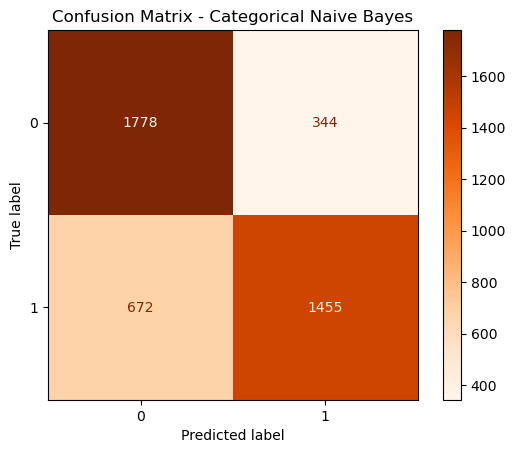

In [54]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predizioni CategoricalNB sullo stesso subset del KNN
X_test_cnb_sub = X_test_cnb[selected_columns]
y_pred_cnb = cnb.predict(X_test_cnb_sub)

# Confusion Matrix (calcolo automatico)
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_cnb,
    cmap=plt.cm.Oranges,
    values_format='d'
)

plt.title('Confusion Matrix - Categorical Naive Bayes')
plt.show()


📈 ROC CURVE - CATEGORICAL NAIVE BAYES


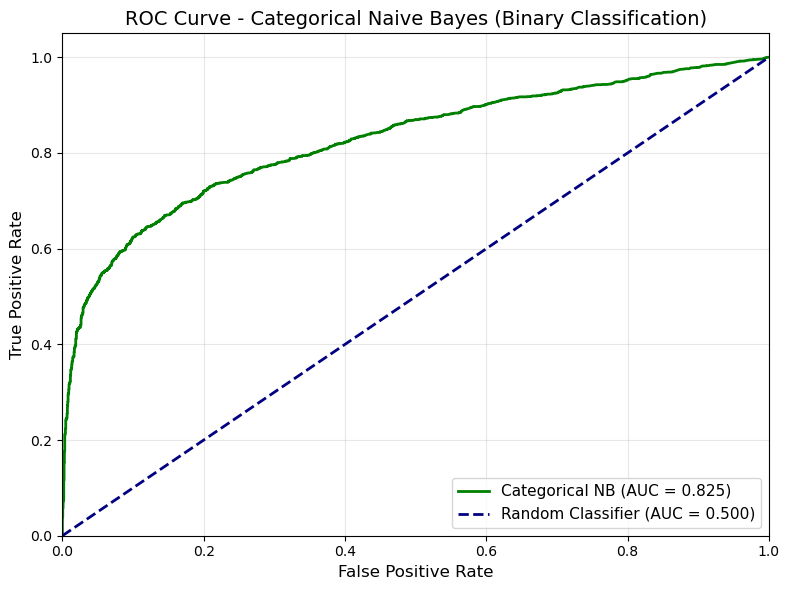


✅ ROC-AUC Score: 0.8255


In [55]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

print("="*60)
print("📈 ROC CURVE - CATEGORICAL NAIVE BAYES")
print("="*60)

# 1. Ottieni probabilità (assicurati che cnb sia già addestrato)
y_proba_cnb = cnb.predict_proba(X_test_cnb)[:, 1]

# 2. Calcola ROC curve
fpr_cnb, tpr_cnb, _ = roc_curve(y_test, y_proba_cnb)
roc_auc_cnb = auc(fpr_cnb, tpr_cnb)

# 3. Plot
plt.figure(figsize=(8, 6))
plt.plot(fpr_cnb, tpr_cnb, color='green', lw=2, 
         label=f'Categorical NB (AUC = {roc_auc_cnb:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', 
         label='Random Classifier (AUC = 0.500)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve - Categorical Naive Bayes (Binary Classification)', fontsize=14)
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n✅ ROC-AUC Score: {roc_auc_cnb:.4f}")

In [56]:
# Per CategorialNB, controlla overfitting
train_acc = accuracy_score(y_train, cnb.predict(X_train_cnb))
test_acc = accuracy_score(y_test, y_pred_cnb)
print(f"Train Accuracy: {train_acc:.4f}")
print(f"Test Accuracy:  {test_acc:.4f}")
print(f"Overfitting Gap: {(train_acc - test_acc)*100:.2f}%")

Train Accuracy: 0.7608
Test Accuracy:  0.7609
Overfitting Gap: -0.01%


0.01% ==> Generalizzazione perfetta!

# DECISION TREES

In [57]:
# ══════════════════════════════════════════════════════════════
# DECISION TREE - usa dataset NON normalizzato
# ══════════════════════════════════════════════════════════════

# Usa le stesse feature del KNN (ma senza scaling)
selected_columns = num_features + bin_features  

X_train_dt = X_train[selected_columns]
X_test_dt = X_test[selected_columns]

print("✅ Dataset preparato per Decision Tree (NON normalizzato)")
print(f"Shape train: {X_train_dt.shape}")
print(f"Shape test:  {X_test_dt.shape}")


✅ Dataset preparato per Decision Tree (NON normalizzato)
Shape train: (16995, 14)
Shape test:  (4249, 14)


### Baseline model (addestrato un primo albero "a mano" con parametri standard (max_depth=10, ecc.)

In [58]:
dt_baseline = DecisionTreeClassifier(
    max_depth=10,
    min_samples_split=50,
    min_samples_leaf=20,
    random_state=42
)
dt_baseline.fit(X_train_dt, y_train)
y_pred_baseline = dt_baseline.predict(X_test_dt)

print("\n" + "="*60)
print("🌳 BASELINE DECISION TREE")
print("="*60)
print(f"Accuracy: {accuracy_score(y_test, y_pred_baseline):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_baseline))


🌳 BASELINE DECISION TREE
Accuracy: 0.7564

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.88      0.78      2122
           1       0.84      0.64      0.72      2127

    accuracy                           0.76      4249
   macro avg       0.77      0.76      0.75      4249
weighted avg       0.77      0.76      0.75      4249



### Grid Search

In [59]:
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [5, 10, 15, 20],  # ❌ Rimosso None
    'min_samples_split': [2, 10, 30, 50],
    'min_samples_leaf': [1, 5, 10, 20],
    'ccp_alpha': [0.0, 0.0001, 0.0005, 0.001]  # ✅ AGGIUNTO
}

grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    verbose=1,
    n_jobs=-1  # ✅ Usa tutti i core
)

grid_search.fit(X_train_dt, y_train)

print("\n" + "="*60)
print("🔍 GRID SEARCH RESULTS")
print("="*60)
print("Best Parameters:", grid_search.best_params_)
print(f"Best CV Score: {grid_search.best_score_:.4f}")

# Valuta sul test set
dt_optimized = grid_search.best_estimator_
y_pred_optimized = dt_optimized.predict(X_test_dt)

print(f"\n🎯 Test Accuracy: {accuracy_score(y_test, y_pred_optimized):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_optimized))



Fitting 5 folds for each of 512 candidates, totalling 2560 fits

🔍 GRID SEARCH RESULTS
Best Parameters: {'ccp_alpha': 0.0005, 'criterion': 'entropy', 'max_depth': 20, 'min_samples_leaf': 5, 'min_samples_split': 30}
Best CV Score: 0.7741

🎯 Test Accuracy: 0.7717

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.86      0.79      2122
           1       0.83      0.69      0.75      2127

    accuracy                           0.77      4249
   macro avg       0.78      0.77      0.77      4249
weighted avg       0.78      0.77      0.77      4249



/opt/anaconda3/lib/python3.12/site-packages/numpy/ma/core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


### Randomized search  

In [60]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# ══════════════════════════════════════════════════════════════
# DECISION TREE - RANDOMIZED SEARCH (BINARY CLASSIFICATION)
# ══════════════════════════════════════════════════════════════

# 1. Definizione dello spazio di ricerca (distribuzioni)
param_dist = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [5, 10, 15, 20, 25, None],
    'min_samples_split': randint(2, 50),
    'min_samples_leaf': randint(1, 20),
    'ccp_alpha': uniform(0, 0.002) 
}

# 2. Inizializzazione ed esecuzione Randomized Search
print("🚀 Avvio Randomized Search (100 iterazioni)...")
random_search = RandomizedSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=100,
    cv=5, 
    scoring='f1_macro',  # ✅ Cambiato da 'accuracy' a 'f1_macro' per bilanciamento
    verbose=1,
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train_dt, y_train)

# 3. Estrazione del miglior modello
dt_random_optimized = random_search.best_estimator_
y_pred_random = dt_random_optimized.predict(X_test_dt)

# 4. REPORT COMPLETO DEI RISULTATI
print("\n" + "="*60)
print("🌳 RANDOMIZED SEARCH - FINAL RESULTS (Binary Classification)")
print("="*60)
print(f"Best Parameters: {random_search.best_params_}")
print(f"Best CV Score:    {random_search.best_score_:.4f}")
print(f"Test Accuracy:    {accuracy_score(y_test, y_pred_random):.4f}")

print("\nDetailed Classification Report:")
# ✅ Target names per binary classification
print(classification_report(y_test, y_pred_random, 
                          target_names=['0: Low Engagement', '1: High Engagement']))



🚀 Avvio Randomized Search (100 iterazioni)...
Fitting 5 folds for each of 100 candidates, totalling 500 fits

🌳 RANDOMIZED SEARCH - FINAL RESULTS (Binary Classification)
Best Parameters: {'ccp_alpha': 0.00047912378133394484, 'criterion': 'entropy', 'max_depth': 25, 'min_samples_leaf': 12, 'min_samples_split': 27}
Best CV Score:    0.7729
Test Accuracy:    0.7727

Detailed Classification Report:
                    precision    recall  f1-score   support

 0: Low Engagement       0.73      0.87      0.79      2122
1: High Engagement       0.84      0.68      0.75      2127

          accuracy                           0.77      4249
         macro avg       0.78      0.77      0.77      4249
      weighted avg       0.78      0.77      0.77      4249



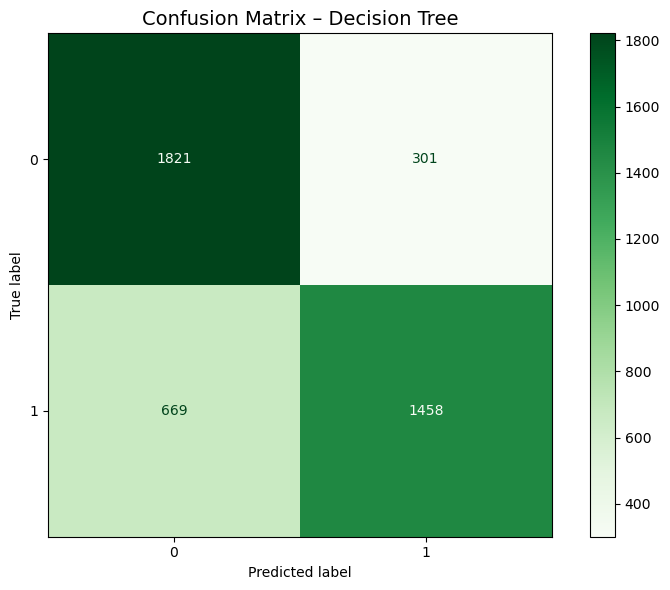

In [61]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Scegli il modello ottimizzato
dt_optimized = grid_search.best_estimator_  
# oppure:
# dt_optimized = random_search.best_estimator_

fig, ax = plt.subplots(figsize=(8, 6))

ConfusionMatrixDisplay.from_estimator(
    dt_optimized,
    X_test_dt,
    y_test,
    display_labels=['0', '1'],
    cmap=plt.cm.Greens,
    normalize= None,   # percentuali per riga (recall per classe)
    ax=ax
)

ax.set_title(
    'Confusion Matrix – Decision Tree',
    fontsize=14,
    #fontweight='bold'
)

plt.tight_layout()
plt.show()


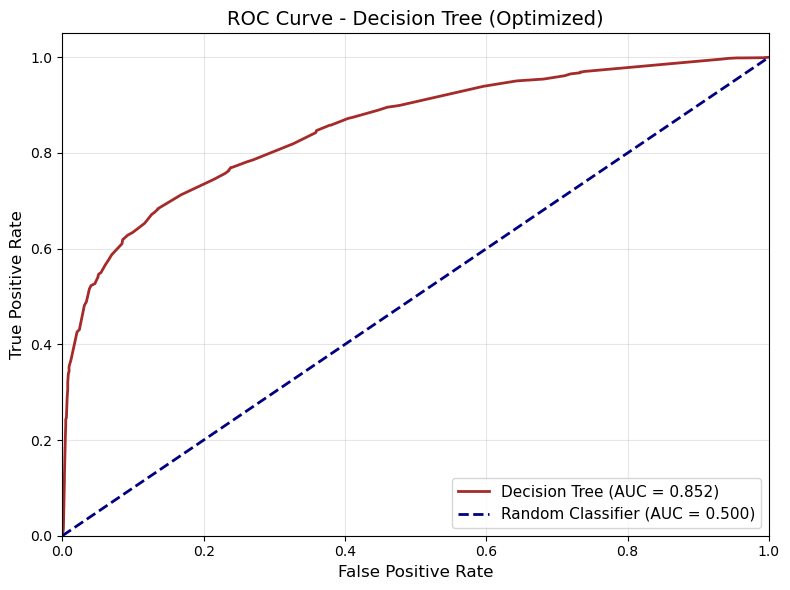


✅ ROC-AUC Score: 0.8520

📊 TOP 10 FEATURE IMPORTANCE
               Feature  Importance
          Cat:Strategy    0.226823
            Cat:Family    0.209439
            GameWeight    0.175915
     NumExpansions_log    0.123055
     NumAlternates_log    0.102812
          Cat:Thematic    0.073970
             Cat:Party    0.034840
         YearPublished    0.021271
            MaxPlayers    0.014018
NumImplementations_log    0.011437


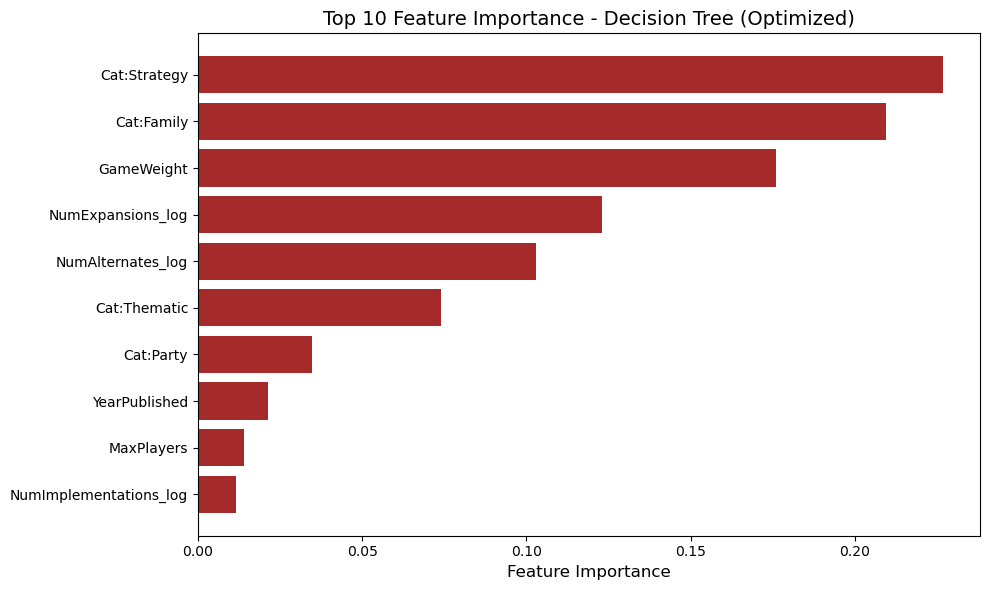

In [62]:
# 7. ROC Curve
from sklearn.metrics import roc_curve, auc

y_proba_dt = dt_random_optimized.predict_proba(X_test_dt)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_proba_dt)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='brown', lw=2, label=f'Decision Tree (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', 
         label='Random Classifier (AUC = 0.500)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve - Decision Tree (Optimized)', fontsize=14)
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n✅ ROC-AUC Score: {roc_auc:.4f}")

# 8. Feature Importance
import pandas as pd

importances = dt_random_optimized.feature_importances_
feature_names = X_train_dt.columns

feature_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print("\n" + "="*60)
print("📊 TOP 10 FEATURE IMPORTANCE")
print("="*60)
print(feature_imp_df.head(10).to_string(index=False))

# Plot
plt.figure(figsize=(10, 6))
top_10 = feature_imp_df.head(10)
plt.barh(top_10['Feature'], top_10['Importance'], color='brown')
plt.xlabel('Feature Importance', fontsize=12)
plt.title('Top 10 Feature Importance - Decision Tree (Optimized)', fontsize=14)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

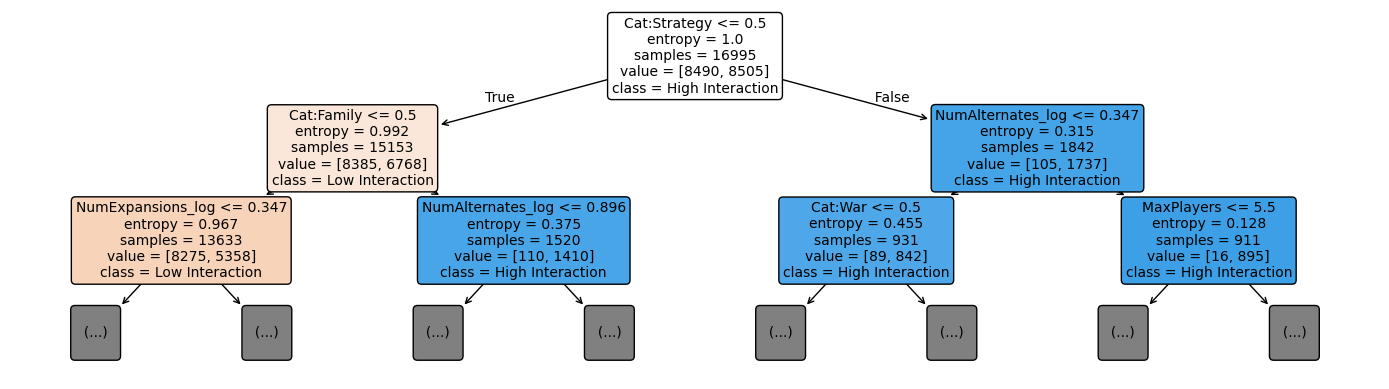

In [84]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# 1) Scegli il modello ottimizzato (grid o random)
dt_optimized = grid_search.best_estimator_    # oppure: grid_search.best_estimator_

# 2) Feature names: devono combaciare con X_test_dt.columns
feature_names = X_test_dt.columns.tolist()

plt.figure(figsize=(14, 4))

plot_tree(
    dt_optimized,
    feature_names=feature_names,
    class_names=['Low Interaction', 'High Interaction'],  # BINARY
    filled=True,
    max_depth=2,       # solo per visualizzazione
    rounded=True,
    fontsize=10
)

#plt.title("Decision Tree Structure (Optimized) – Binary Engagement Classification", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()


In [66]:
# Dopo ogni modello
train_acc = accuracy_score(y_train, dt_optimized.predict(X_train_dt))
test_acc = accuracy_score(y_test, y_pred_random)
print(f"Train Accuracy: {train_acc:.4f}")
print(f"Test Accuracy:  {test_acc:.4f}")
print(f"Overfitting Gap: {(train_acc - test_acc)*100:.2f}%")

Train Accuracy: 0.7864
Test Accuracy:  0.7727
Overfitting Gap: 1.38%
